In [1]:
req_ratios = [1, 1.25, 1.5, 1.75, 2]
sched_paths = [f"sched_request{x}_threshold07" for x in req_ratios]
offloading_paths = [f"offloading_request{x}_threshold07" for x in req_ratios]
native_paths = [f"native_request{x}_threshold07" for x in req_ratios]
core_ratio = ["13_6", "10_9"]

In [2]:
import json

import numpy as np


def merge_metric(a, b):
    data = {
        "ttft": np.concatenate([a["ttft"], b["ttft"]]),
        "tpot": np.concatenate([a["tpot"], b["tpot"]]),
        "ttft_slo": np.concatenate([a["ttft_slo"], b["ttft_slo"]]),
        "latency": np.concatenate([a["latency"], b["latency"]]),
        "finish_time": max(a["finish_time"], b["finish_time"]),
    }
    return data


def load_metric(path):
    fp = open(f"../tmp/{path}.json")
    data = json.load(fp)
    fp.close()
    raw = data["raw"]
    statics = data["statics"]
    data = {
        "ttft": raw["TTFT_TEE"],
        "tpot": raw["TPOT_TEE"],
        "ttft_slo": raw["TTFT_SLO_TEE"],
        "latency": raw["LATENCY_TEE"],
        "finish_time": max(raw["FINISH_TIME_TEE"]),
    }
    data = {k: np.array(v) for (k, v) in sorted(data.items())}
    return data

In [3]:
import os
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)


all_metric = []
for type_label, paths in zip(
    ["SecureRAG", "Sched-SecureRAG"],
    [
        offloading_paths,
        sched_paths,
    ],
):
    ttft = []
    tpot = []
    ttft_slo = []
    latency = []
    for idx, _ in enumerate(req_ratios):
        metric = load_metric(paths[idx])
        ttft.append(metric["ttft"].mean())
        tpot.append(metric["tpot"].mean())
        latency.append(metric["latency"].mean())
        ttft_slo.append(metric["ttft_slo"].sum() / 64)
    all_metric.append([ttft, tpot, ttft_slo, latency])

for cr in core_ratio:
    ttft = []
    tpot = []
    ttft_slo = []
    latency = []
    strong_instance_paths = [f"strong_tee{cr}_request{x}" for x in req_ratios]
    weak_instance_paths = [f"weak_tee{cr}_request{x}" for x in req_ratios]
    for idx, _ in enumerate(req_ratios):
        s = load_metric(strong_instance_paths[idx])
        w = load_metric(weak_instance_paths[idx])
        metric = merge_metric(s, w)
        ttft.append(metric["ttft"].mean())
        tpot.append(metric["tpot"].mean())
        latency.append(metric["latency"].mean())
        ttft_slo.append(metric["ttft_slo"].sum() / 64)
    all_metric.append([ttft, tpot, ttft_slo, latency])

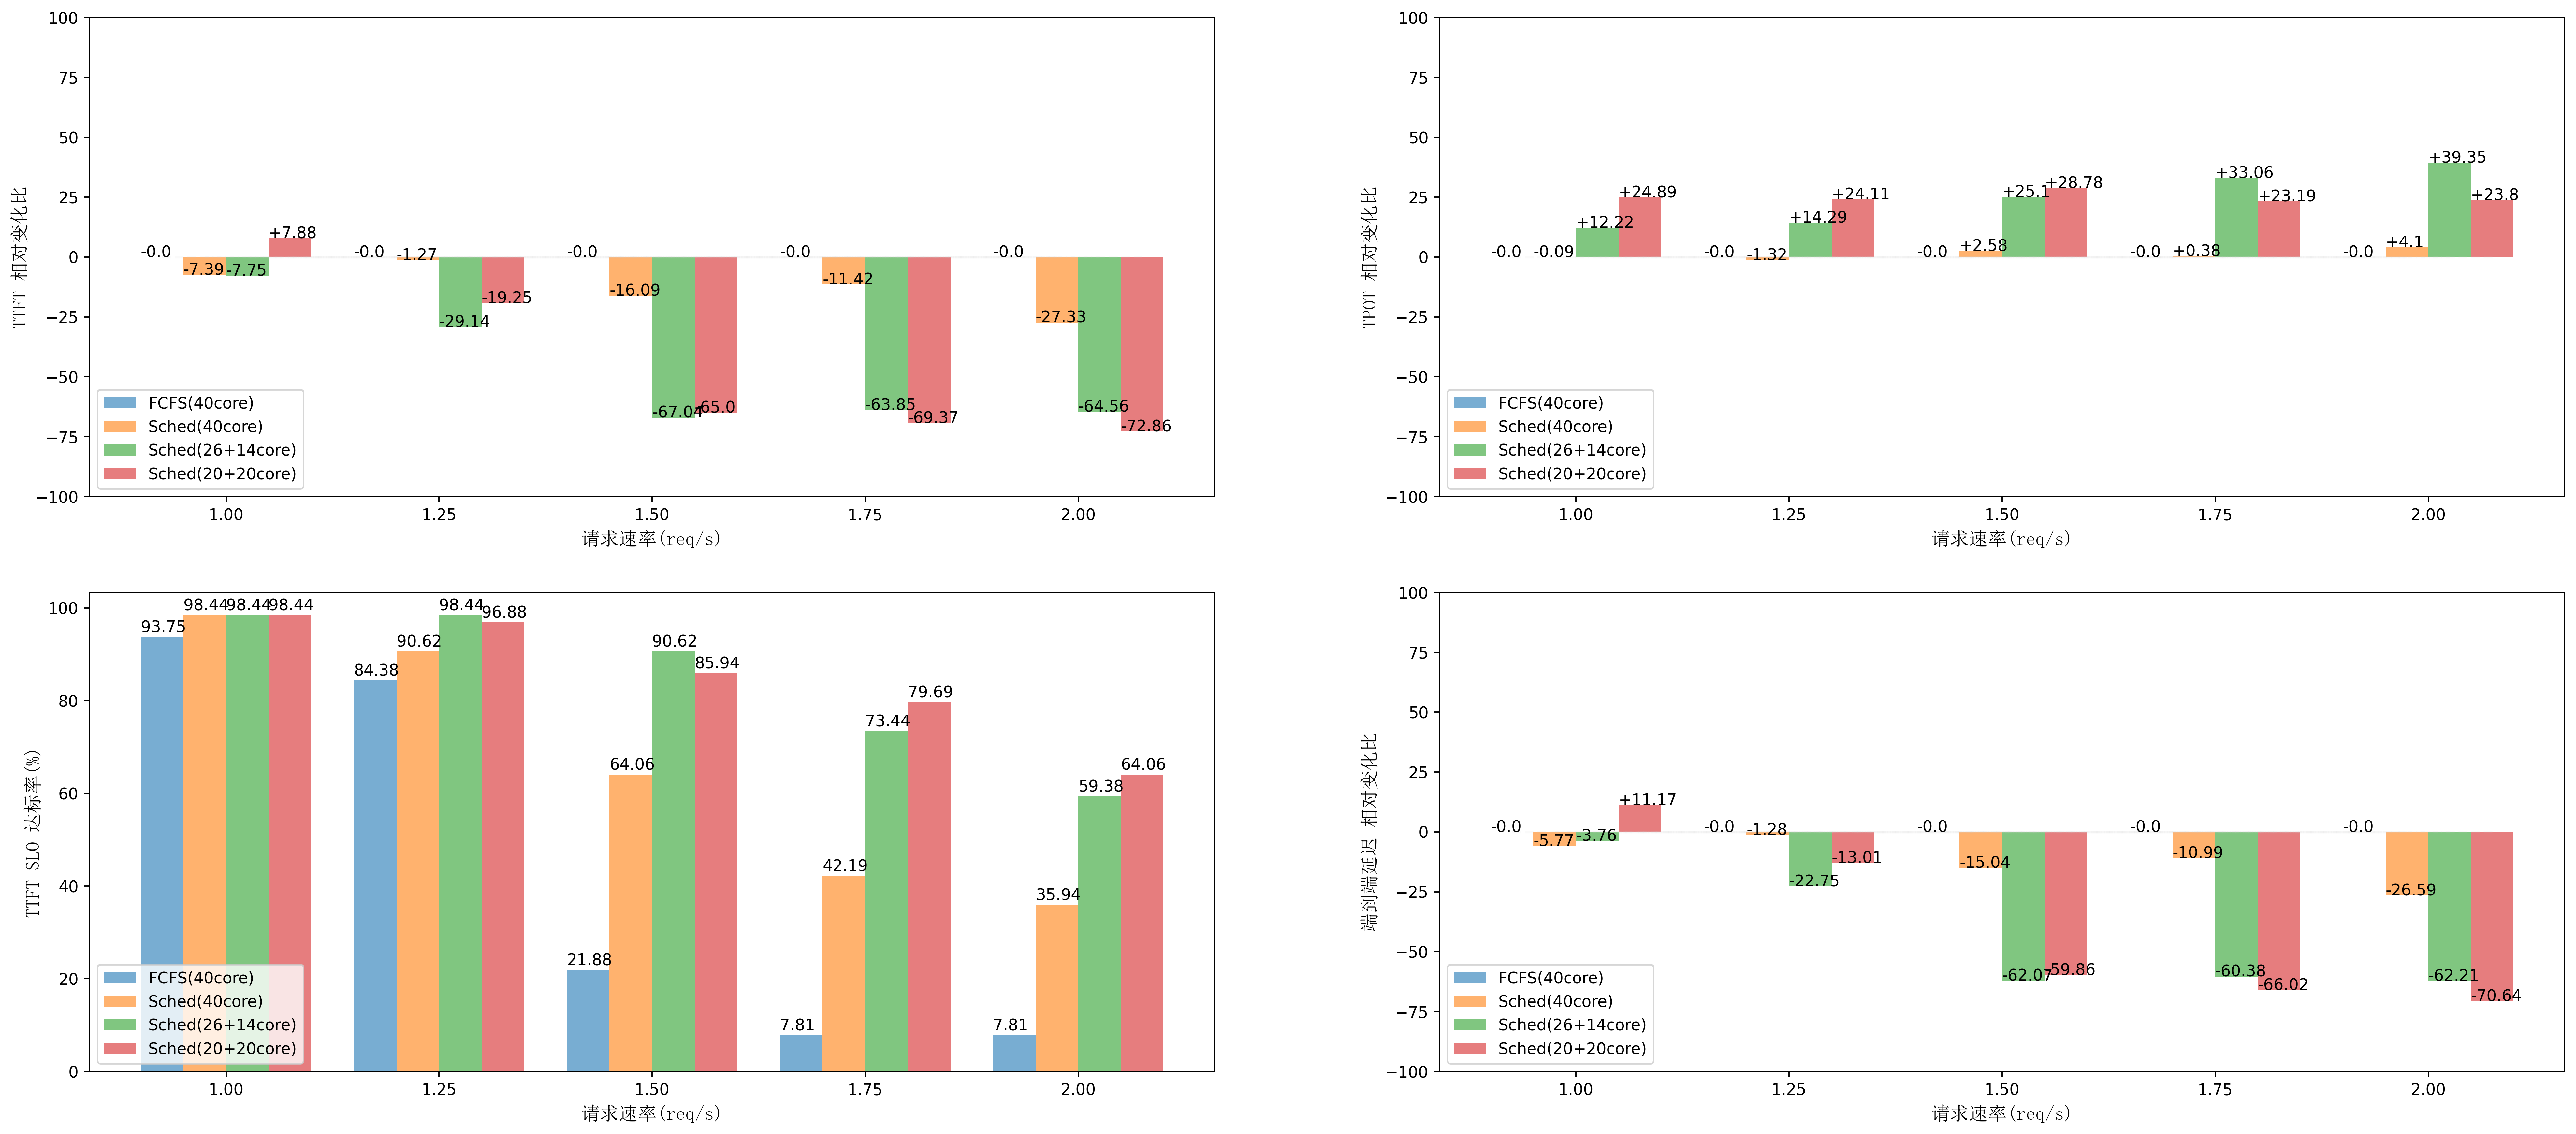

In [4]:
def plot():
    fig, axes = plt.subplots(2, 2, figsize=(28, 12), dpi=350)
    # axes2 = [ax.twinx() for ax in axes.flatten()]
    global all_metric
    all_metric = [[np.array(x) for x in m] for m in all_metric]
    # [
    # 0 Sched: [[ttft], ...]
    # 1 Secure: [[ttft], ...]
    # 2 26+14core: [[ttft], ...]
    # 3 20+20score: [[ttft], ...]
    # ]

    def get_speedup(native, ours):
        up = []
        for i in range(4):
            up.append(
                (all_metric[native][i] - all_metric[ours][i])
                / all_metric[native][i]
                * 100
            )
        return up

    for type_idx, (type_label, metric) in enumerate(
        zip(
            [
                "FCFS(40core)",
                "Sched(40core)",
                "Sched(26+14core)",
                "Sched(20+20core)",
            ],
            all_metric,
        )
    ):
        for metric_idx, (y, metric_label, ax, ax2) in enumerate(
            zip(
                metric,
                ["TTFT", "TPOT", "TTFT SLO", "端到端延迟"],
                axes.flatten(),
                axes.flatten(), # axes2,
            )
        ):
            x = req_ratios
            if metric_label == "TTFT SLO":
                x = np.array(x)
                x = x - 0.075 + 0.05 * type_idx
                y = np.array(y).round(4) * 100
                ax.bar(x, y, width=0.05, label=type_label, alpha=0.6)
                ax.set_ylabel(f"{metric_label} 达标率(%)", fontproperties=font)
                for a, b in zip(x, y):
                    # if a == 1.05:
                    #     ax.text(a, b + 1, f"{round(b,4)}%")
                    #     continue
                    ax.text(a - 0.025, b + 1, f"{round(b,4)}")
            else:
                # ax.plot(x, y, label=type_label, alpha=0.5)
                # ax.scatter(x, y)
                # if type_idx == 0:
                #     ax.set_ylim(-1.2 * max(y), 1.2 * max(y))
                # ax.set_ylabel(f"{metric_label}(s)", fontproperties=font)

                speedup = get_speedup(0, type_idx)[metric_idx]
                speedup = np.array(speedup) * -1
                x = np.array(x)
                x = x - 0.075 + 0.05 * type_idx
                ax.bar(x, speedup, label=type_label, width=0.05, alpha=0.6)
                ax.plot(
                    x, np.zeros_like(x), alpha=0.1, color="lightgray", linestyle="--"
                )
                ax.set_ylim(-100, 100)
                x = x - 0.025
                for r_idx, (a, b) in enumerate(zip(x, speedup)):
                    ax.text(
                        a,
                        b,
                        f"{'+'if speedup[r_idx] > 0 else ''}{round(speedup[r_idx], 2)}",
                    )
                ax.set_ylabel(f"{metric_label} 相对变化比", fontproperties=font)
            ax.set_xlabel("请求速率(req/s)", fontproperties=font)
            ax.legend(loc="lower left")
            ax2.legend(loc="lower left")
            ax.set_xticks(req_ratios)


plot()

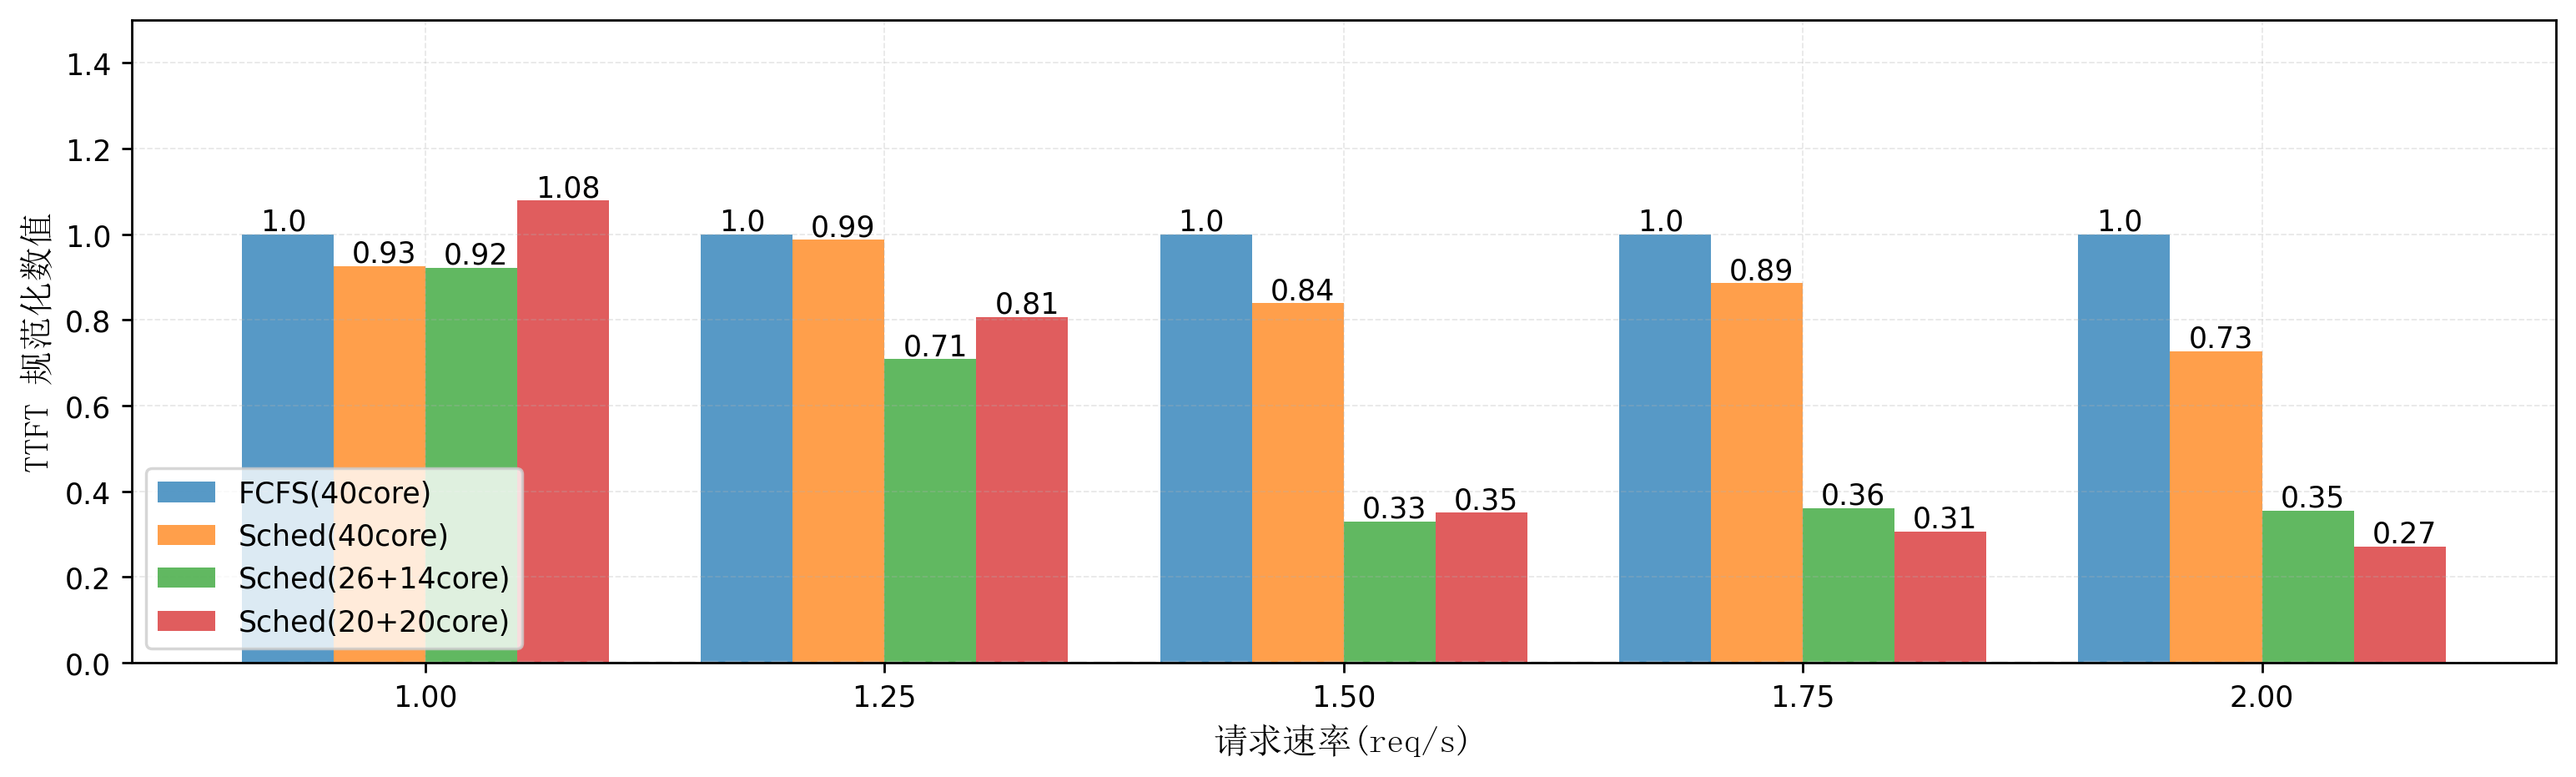

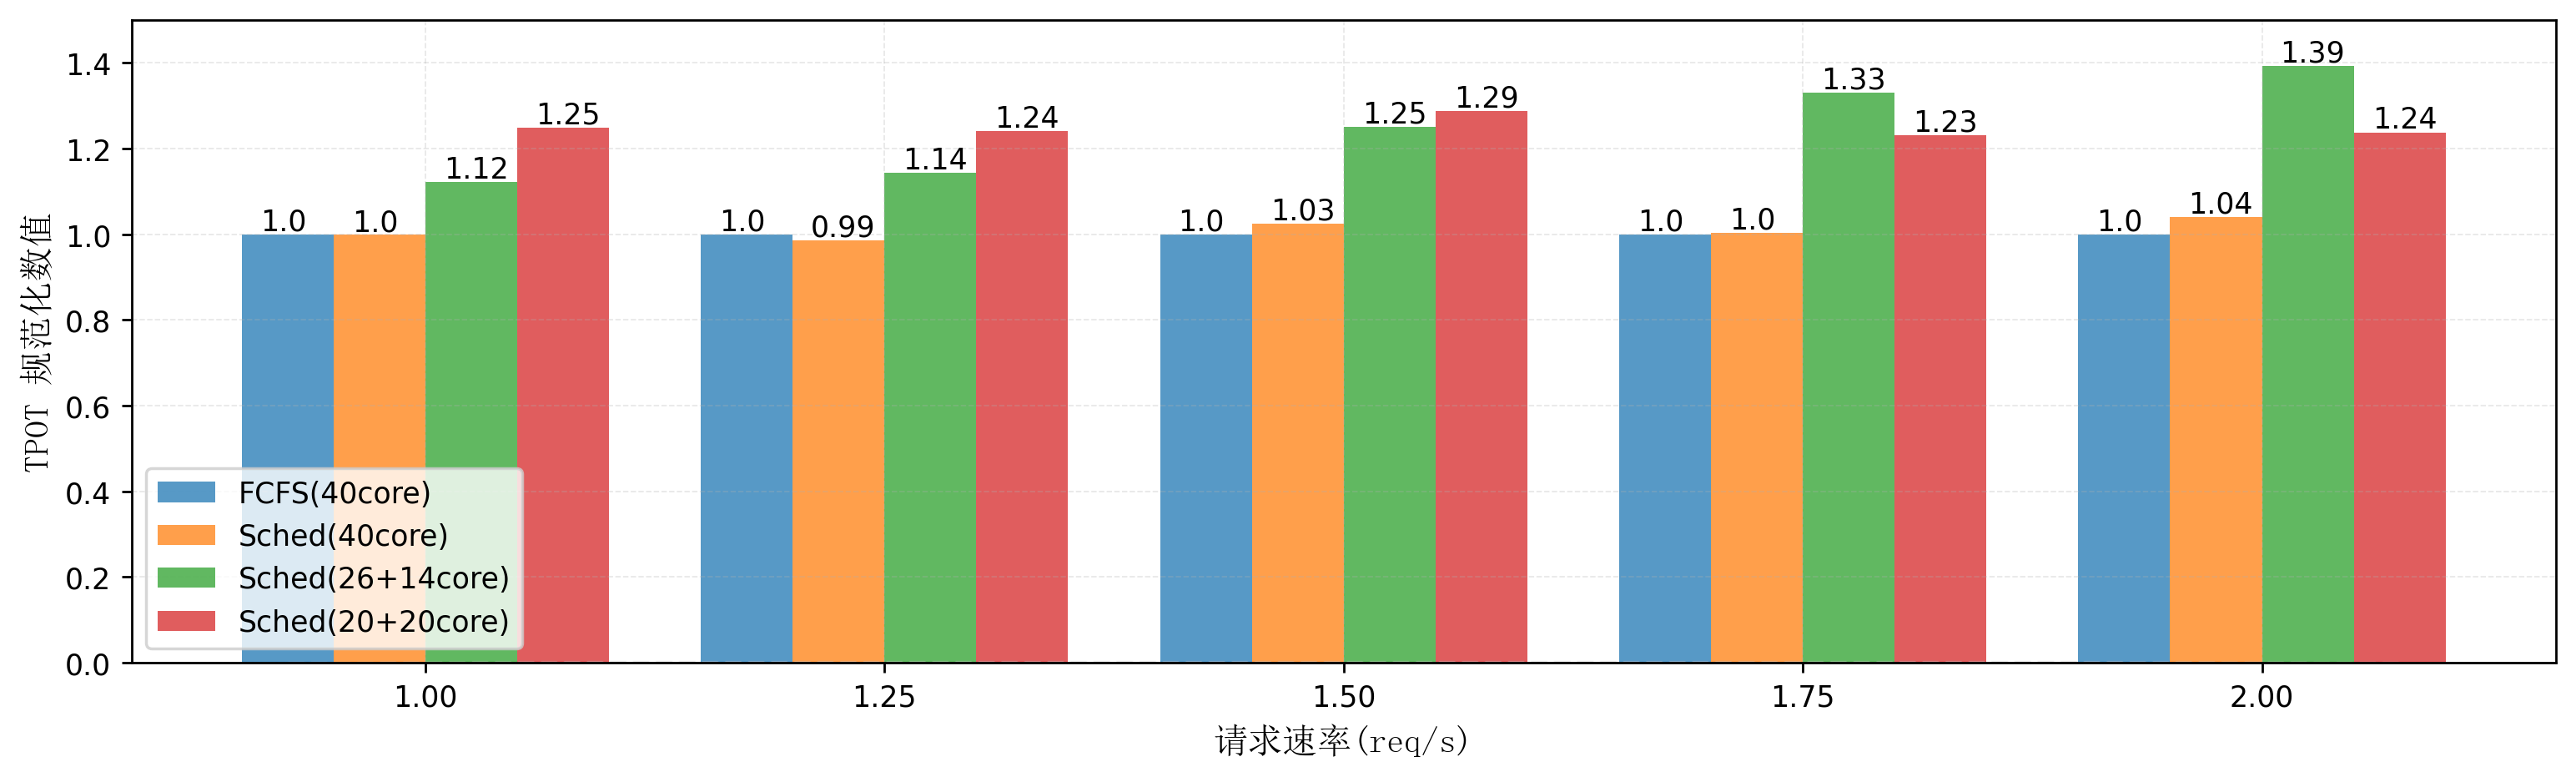

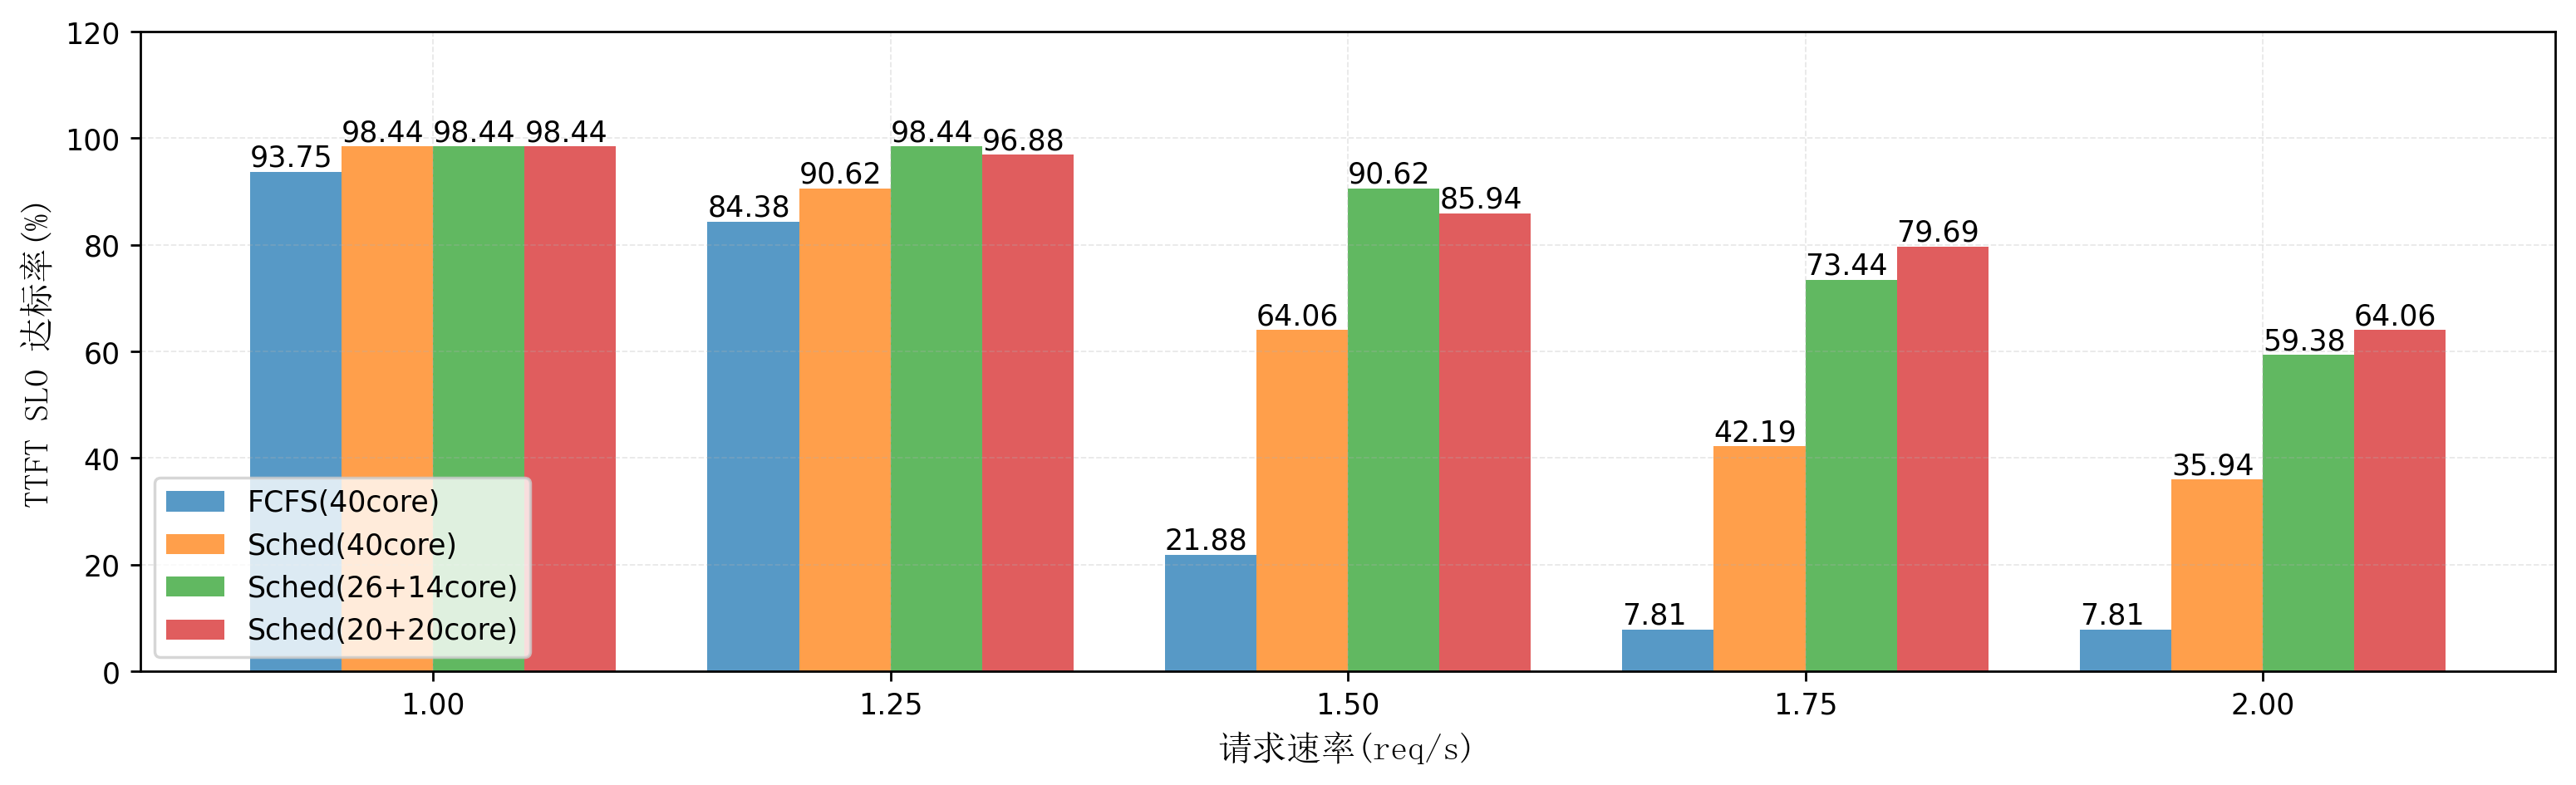

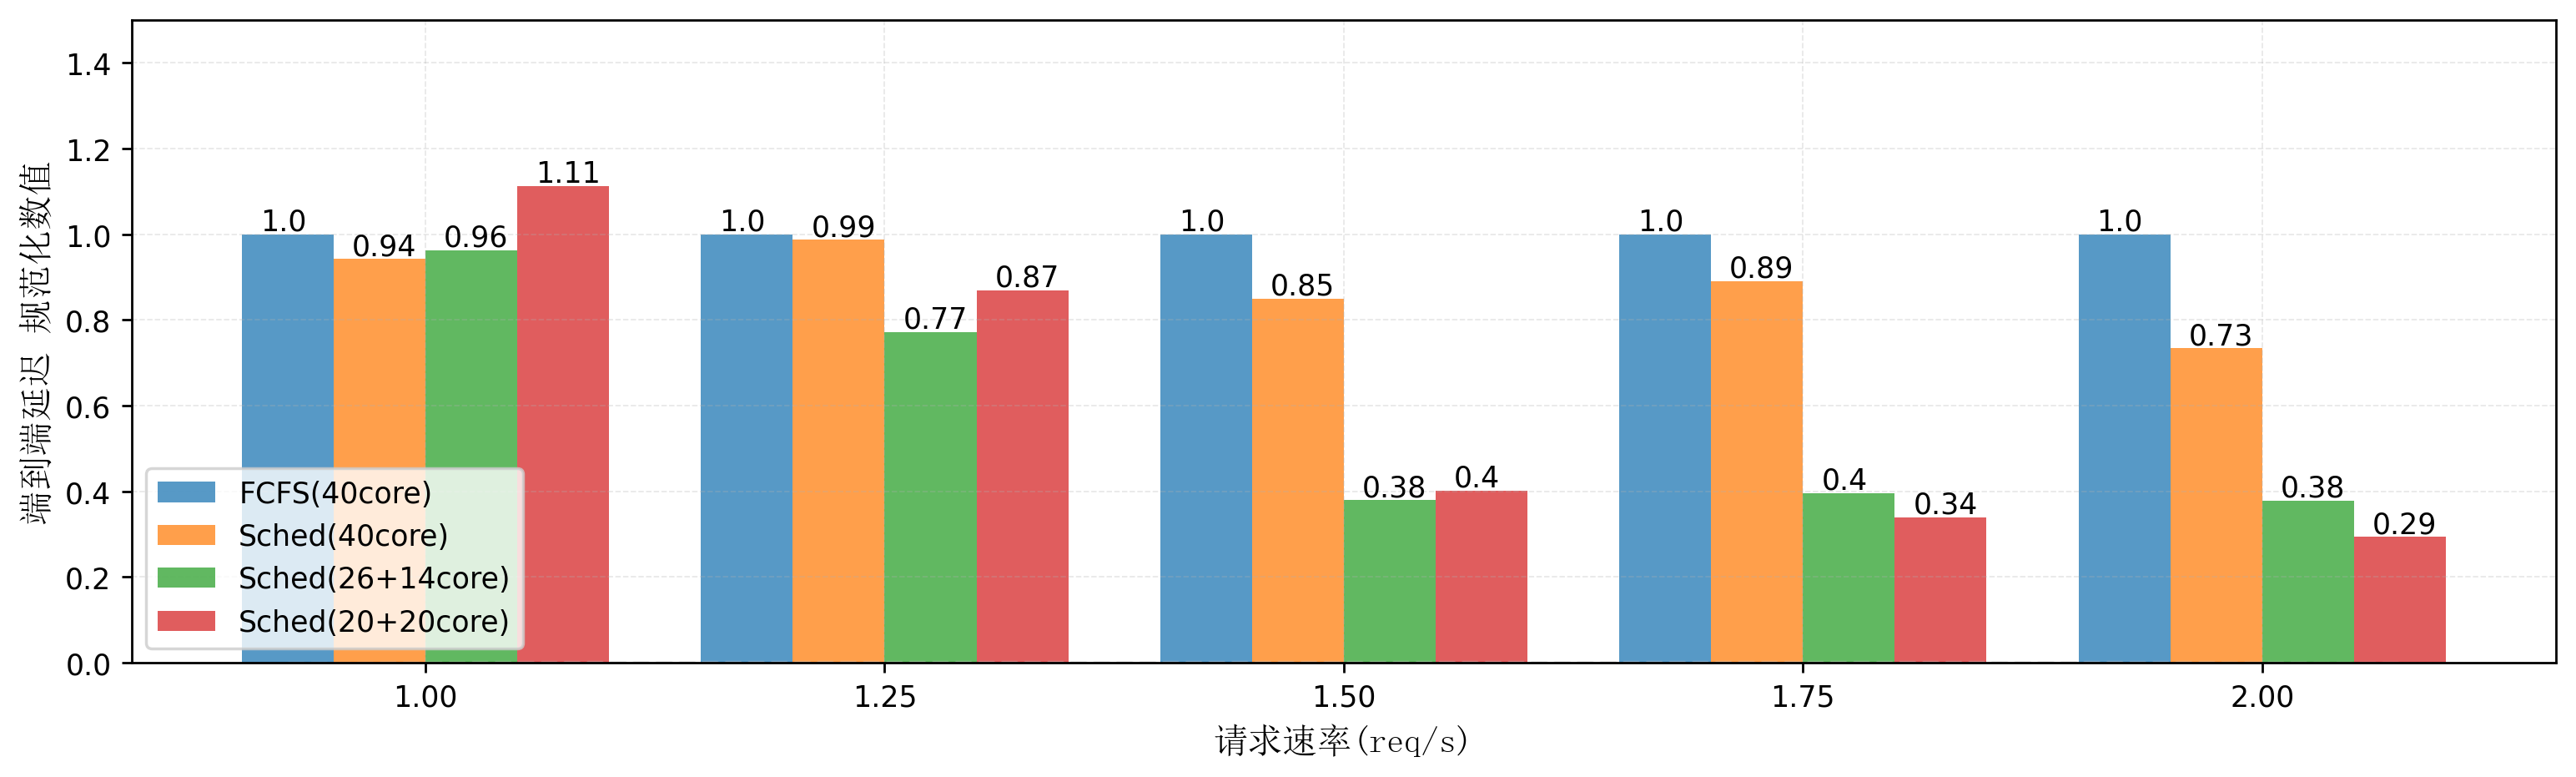

In [20]:
def plot(all_metric):
    all_metric_transpose = np.array(all_metric)
    all_metric_transpose = all_metric_transpose.transpose(1, 0, 2)
    all_metric_transpose = [[np.array(x) for x in m] for m in all_metric_transpose]
    # [
    # 0 Sched: [[ttft], ...]
    # 1 Secure: [[ttft], ...]
    # 2 26+14core: [[ttft], ...]
    # 3 20+20score: [[ttft], ...]
    # ]

    def get_speedup(native, ours):
        up = []
        global all_metric
        for i in range(4):
            up.append(
                1 - ((all_metric[native][i] - all_metric[ours][i])
                / all_metric[native][i])
            )
        return up

    for metric_idx, (metric, metric_label) in enumerate(
        zip(
            all_metric_transpose,
            ["TTFT", "TPOT", "TTFT SLO", "端到端延迟"],
        )
    ):
        plt.figure(dpi=250, figsize=(15,4))
        for type_idx, (type_label, y) in enumerate(
            zip(
                [
                    "FCFS(40core)",
                    "Sched(40core)",
                    "Sched(26+14core)",
                    "Sched(20+20core)",
                ],
                metric,
            )
        ):
            x = req_ratios
            if metric_label == "TTFT SLO":
                x = np.array(x)
                x = x - 0.075 + 0.05 * type_idx
                y = np.array(y).round(4) * 100
                plt.bar(x, y, width=0.05, label=type_label, alpha=0.75)
                plt.ylabel(f"{metric_label} 达标率(%)", fontproperties=font)
                for a, b in zip(x, y):
                    # if a == 1.05:
                    #     plt.text(a, b + 1, f"{round(b,4)}%")
                    #     continue
                    plt.text(a - 0.025, b + 1, f"{round(b,4)}")
                plt.ylim(0, 120)
            else:
                # plt.plot(x, y, label=type_label, alpha=0.5)
                # plt.scatter(x, y)
                # if type_idx == 0:
                #     plt.ylim(-1.2 * max(y), 1.2 * max(y))
                # plt.ylabel(f"{metric_label}(s)", fontproperties=font)

                speedup = get_speedup(0, type_idx)[metric_idx]
                speedup = np.array(speedup)
                x = np.array(x)
                x = x - 0.075 + 0.05 * type_idx
                plt.bar(x, speedup, label=type_label, width=0.05, alpha=0.75)
                plt.plot(
                    x, np.zeros_like(x), alpha=0.1, color="lightgray", linestyle="--"
                )
                # plt.ylim(-100, 100)
                x = x - 0.015
                for r_idx, (a, b) in enumerate(zip(x, speedup)):
                    plt.text(
                        a,
                        b + 0.01,
                        f"{round(speedup[r_idx], 2)}",
                    )
                plt.ylim(0, 1.5)
                plt.ylabel(f"{metric_label} 规范化数值", fontproperties=font)
            plt.xlabel("请求速率(req/s)", fontproperties=font)
            plt.legend(loc="lower left")
            plt.xticks(req_ratios)
            plt.grid(
                True,
                linestyle='--',   # 虚线
                linewidth=0.5,    # 线宽
                alpha=0.3         # 透明度
            )


plot(all_metric)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cores = np.linspace(0, 20, 11, dtype=int)
tee_core_paths = [f"../tmp/tee_core_{x}.json" for x in cores]
tee_core_metrics = []


def load_metric():
    for path in tee_core_paths:
        fp = open(path)
        data = json.load(fp)
        cpu_decoder_time = data["statics"]["cpu_DECODER(statics)"]
        cpu_encoder_time = data["statics"]["cpu_ENCODER(statics)"]
        tee_core_metrics.append([cpu_decoder_time[0], cpu_encoder_time[0]])
        fp.close()


load_metric()

In [ ]:
def plot_core():
    global tee_core_metrics
    font_path = "../tmp/SimSun.ttc"
    font = FontProperties(fname=font_path, size=12)

    tee_core_metrics = np.array(tee_core_metrics)
    x = np.array(cores) * 2
    x[0] = 1
    y_decoder = tee_core_metrics[:, 0].squeeze()
    y_encoder = tee_core_metrics[:, 1].squeeze()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=250)
    for ax, tag, y in zip(
        axes.flatten(), ["Encoder", "Decoder"], [y_encoder, y_decoder]
    ):
        ax.plot(x, y, label=tag)
        ax.scatter(x, y)
        # ax.set_xticks(x)
        ax.set_title(tag)
        ax.set_ylabel("执行时间(秒)", fontproperties=font)
        ax.set_xlabel("CPU 核心数量", fontproperties=font)


plot_core()